📍 Jupyter đang đứng tại: /workspace
📂 Tìm thấy 23580 file. 5 file đầu tiên: ['b1c66a42-6f7d68ca-checkpoint_real_A.png', 'b1c66a42-6f7d68ca-checkpoint_fake_B.png', 'b1c66a42-6f7d68ca-checkpoint_rec_A.png', 'b1c66a42-6f7d68ca-checkpoint_real_B.png', 'b1c66a42-6f7d68ca-checkpoint_fake_A.png']


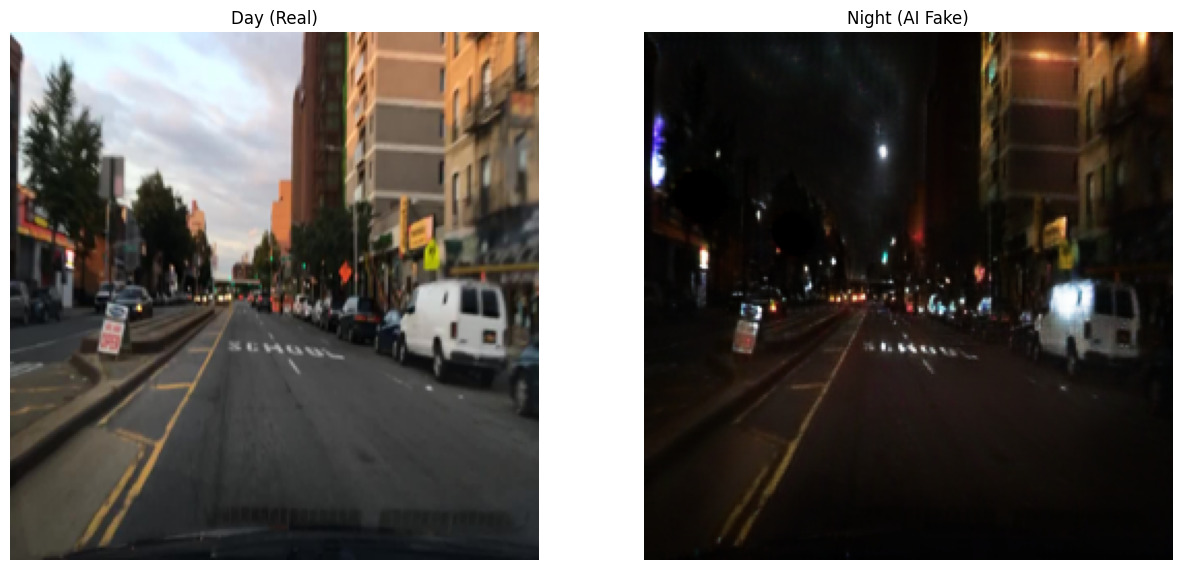

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def compare_results_v2(image_id, results_dir):
    # 1. Kiểm tra xem Jupyter đang đứng ở đâu
    print(f"📍 Jupyter đang đứng tại: {os.getcwd()}")
    
    # 2. Kiểm tra thư mục có tồn tại không
    if not os.path.exists(results_dir):
        print(f"Thư mục không tồn tại: {os.path.abspath(results_dir)}")
        return

    # 3. Liệt kê 5 file đầu tiên để kiểm tra định dạng thực tế
    files_in_dir = os.listdir(results_dir)
    print(f"📂 Tìm thấy {len(files_in_dir)} file. 5 file đầu tiên: {files_in_dir[:5]}")

    # 4. Định nghĩa tên file (Dựa trên kết quả ls của Elaine)
    # Lưu ý: Kiểm tra xem có dấu gạch chéo dư thừa không
    real_A_path = os.path.join(results_dir, f"{image_id}-checkpoint_real_A.png")
    fake_B_path = os.path.join(results_dir, f"{image_id}-checkpoint_fake_B.png")
    
    if not os.path.exists(real_A_path):
        print(f"Không thấy file Real_A tại: {real_A_path}")
        # Thử tìm kiếm mờ (fuzzy search) xem có file nào chứa ID đó không
        match = [f for f in files_in_dir if image_id in f]
        print(f"🔍 Gợi ý các file có chứa mã '{image_id}': {match}")
        return

    # 5. Vẽ ảnh
    img_real = Image.open(real_A_path)
    img_fake = Image.open(fake_B_path)
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].imshow(img_real); axes[0].set_title("Day (Real)"); axes[0].axis('off')
    axes[1].imshow(img_fake); axes[1].set_title("Night (AI Fake)"); axes[1].axis('off')
    plt.show()

# --- CHẠY THỬ ---
# Dùng đường dẫn tuyệt đối để chắc chắn 100%
res_dir = '/workspace/pytorch-CycleGAN-and-pix2pix/results/bdd_final_test/bdd_resnet9_10ep/test_latest/images'
compare_results_v2('b1c66a42-6f7d68ca', res_dir)